In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.0f}".format

In [2]:
import numpy as np
import pandas as pd

# Fixed seed: everyone gets the same data
rng = np.random.default_rng(42)

cities = ["Seoul", "Busan", "Incheon", "Daegu", "Daejeon", "Gwangju"]

customers = pd.DataFrame({
    "customer_id": range(1001, 1061),
    "customer_name": [f"Customer_{i}" for i in range(1, 61)],
    "city": rng.choice(
        cities,
        60,
        p=[0.35, 0.2, 0.15, 0.1, 0.1, 0.1]
    ),
    "segment": rng.choice(
        ["Regular", "Premium"],
        60,
        p=[0.75, 0.25]
    ),
})

catalog = {
    "Electronics": [
        ("Wireless Earbuds", 59000),
        ("Phone Charger", 25000),
        ("Smart Watch", 189000),
    ],
    "Home & Kitchen": [
        ("Air Fryer", 99000),
        ("Rice Cooker", 129000),
        ("Water Bottle", 18000),
    ],
    "Fashion": [
        ("Running Shoes", 89000),
        ("Winter Jacket", 159000),
        ("Backpack", 49000),
    ],
    "Beauty": [
        ("Sunscreen", 22000),
        ("Face Serum", 45000),
        ("Hand Cream", 12000),
    ],
}

n = 300
rows = []

for i in range(n):
    cat = rng.choice(list(catalog))

    prod, price = catalog[cat][rng.integers(0, 3)]

    day = (
        pd.Timestamp("2026-03-01")
        + pd.Timedelta(days=int(rng.integers(0, 180)))
    )

    rows.append({
        "order_id": 5001 + i,
        "customer_id": int(
            rng.choice(customers["customer_id"].iloc[:50])
        ),
        "order_date": day.strftime("%Y-%m-%d"),
        "category": cat,
        "product": prod,
        "unit_price": f"\u20a9{price:,}",
        "quantity": float(rng.integers(1, 5)),
        "payment_method": rng.choice(
            ["Card", "KakaoPay", "Bank Transfer"]
        ),
    })

# Convert rows into a DataFrame
orders = pd.DataFrame(rows)

# -------------------------------------------------
# Make the data realistically messy
# -------------------------------------------------

# Add missing quantity values
orders.loc[
    rng.choice(n, 15, replace=False),
    "quantity"
] = np.nan

# Add missing payment methods
orders.loc[
    rng.choice(n, 20, replace=False),
    "payment_method"
] = np.nan

# Change some category names to lowercase
orders.loc[
    rng.choice(n, 40, replace=False),
    "category"
] = orders["category"].str.lower()

# Add spaces around some category names
orders.loc[
    rng.choice(n, 25, replace=False),
    "category"
] = " " + orders["category"] + " "

# Add customer IDs that do not exist in the CRM
orders.loc[[10, 11, 12], "customer_id"] = 9999

# Add 12 duplicated orders
orders = pd.concat(
    [
        orders,
        orders.sample(12, random_state=1)
    ],
    ignore_index=True
)

# Shuffle the rows
orders = (
    orders
    .sample(frac=1, random_state=7)
    .reset_index(drop=True)
)

# Save the generated files
orders.to_csv(
    "orders_raw.csv",
    index=False,
    encoding="utf-8-sig"
)

customers.to_csv(
    "customers.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Created orders_raw.csv and customers.csv")
print("Orders shape:", orders.shape)
print("Customers shape:", customers.shape)

Created orders_raw.csv and customers.csv
Orders shape: (312, 8)
Customers shape: (60, 4)


In [3]:
orders = pd.read_csv("orders_raw.csv")
customers = pd.read_csv("customers.csv")
print("orders :", orders.shape)
print("customers:", customers.shape)
orders.head(8)

orders : (312, 8)
customers: (60, 4)


,order_id,customer_id,order_date,category,product,unit_price,quantity,payment_method
0,5285,1046,2026-03-29,Home & Kitchen,Air Fryer,"₩99,000",1,Card
1,5171,1042,2026-05-20,Home & Kitchen,Water Bottle,"₩18,000",1,Card
2,5151,1043,2026-08-15,Beauty,Face Serum,"₩45,000",2,KakaoPay
3,5105,1042,2026-07-26,Beauty,Hand Cream,"₩12,000",2,Card
4,5038,1049,2026-03-02,Fashion,Winter Jacket,"₩159,000",1,KakaoPay
5,5102,1031,2026-07-26,Electronics,Wireless Earbuds,"₩59,000",4,Bank Transfer
6,5267,1028,2026-04-10,Beauty,Sunscreen,"₩22,000",2,Card
7,5243,1035,2026-03-29,fashion,Winter Jacket,"₩159,000",2,Card


In [4]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        312 non-null    int64  
 1   customer_id     312 non-null    int64  
 2   order_date      312 non-null    str    
 3   category        312 non-null    str    
 4   product         312 non-null    str    
 5   unit_price      312 non-null    str    
 6   quantity        297 non-null    float64
 7   payment_method  291 non-null    str    
dtypes: float64(1), int64(2), str(5)
memory usage: 19.6 KB


In [5]:
print("\n--- Missing values per column ---")
print(orders.isna().sum())
print("\nFully duplicated rows:", orders.duplicated().sum())


--- Missing values per column ---
order_id           0
customer_id        0
order_date         0
category           0
product            0
unit_price         0
quantity          15
payment_method    21
dtype: int64

Fully duplicated rows: 12


In [6]:
print(orders["category"].value_counts())
print("\nSample prices:", orders["unit_price"].head(3).tolist())


category
Beauty              68
Fashion             68
Home & Kitchen      56
Electronics         53
home & kitchen      12
fashion             11
electronics          9
beauty               9
 Home & Kitchen      8
 Fashion             7
 Electronics         5
 Beauty              4
 electronics         1
 home & kitchen      1
Name: count, dtype: int64

Sample prices: ['₩99,000', '₩18,000', '₩45,000']


In [7]:
print(orders.columns.tolist())

['order_id', 'customer_id', 'order_date', 'category', 'product', 'unit_price', 'quantity', 'payment_method']


In [8]:
# -----------------------------------------
# Restore cleaned orders before Part 3
# -----------------------------------------

# Remove duplicated rows
orders = orders.drop_duplicates().copy()

# Convert unit_price to numeric if necessary
if not pd.api.types.is_numeric_dtype(orders["unit_price"]):
    orders["unit_price"] = (
        orders["unit_price"]
        .str.replace("₩", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

# Convert order_date to datetime
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Standardise category labels
orders["category"] = (
    orders["category"]
    .str.strip()
    .str.title()
)

# Handle missing quantity
orders["quantity"] = (
    orders["quantity"]
    .fillna(orders["quantity"].median())
    .astype(int)
)

# Handle missing payment methods
orders["payment_method"] = (
    orders["payment_method"]
    .fillna("Unknown")
)

# Create revenue
orders["revenue"] = (
    orders["unit_price"] * orders["quantity"]
)

# Create month
orders["month"] = (
    orders["order_date"]
    .dt.strftime("%Y-%m")
)

print("Orders shape:", orders.shape)
print("\nColumns:")
print(orders.columns.tolist())

print("\nRevenue column created:", "revenue" in orders.columns)

Orders shape: (300, 10)

Columns:
['order_id', 'customer_id', 'order_date', 'category', 'product', 'unit_price', 'quantity', 'payment_method', 'revenue', 'month']

Revenue column created: True


In [9]:
assert orders.duplicated().sum() == 0
assert orders.isna().sum().sum() == 0
assert orders["unit_price"].dtype == "float64"
assert pd.api.types.is_datetime64_any_dtype(orders["order_date"])
assert orders["category"].nunique() == 4
assert "revenue" in orders.columns
assert "month" in orders.columns

print("✅ Validation successful.")
print("Rows:", len(orders))
print("Total revenue:", f"₩{orders['revenue'].sum():,.0f}")

✅ Validation successful.
Rows: 300
Total revenue: ₩53,904,000


In [10]:
print("Orders before merge:", len(orders))

inner = pd.merge(
    orders,
    customers,
    on="customer_id",
    how="inner"
)

print("Rows after INNER join:", len(inner))

merged = pd.merge(
    orders,
    customers,
    on="customer_id",
    how="left",
    indicator=True
)

print("Rows after LEFT join :", len(merged))

merged["_merge"].value_counts()

Orders before merge: 300
Rows after INNER join: 297
Rows after LEFT join : 300


_merge
both          297
left_only       3
right_only      0
Name: count, dtype: int64

In [11]:
orphans = merged[
    merged["_merge"] == "left_only"
]

orphans[
    ["order_id", "customer_id", "revenue"]
]

,order_id,customer_id,revenue
106,5012,9999,"387,000"
245,5013,9999,"177,000"
267,5011,9999,"54,000"


In [12]:
print(
    "Unmatched revenue:",
    f"₩{orphans['revenue'].sum():,.0f}"
)

Unmatched revenue: ₩618,000


In [13]:
for col in ["city", "segment", "customer_name"]:
    merged[col] = merged[col].fillna("Unknown")

df = merged.drop(columns="_merge")

print("Final merged shape:", df.shape)

df.head()

Final merged shape: (300, 13)


,order_id,customer_id,order_date,category,product,unit_price,quantity,payment_method,revenue,month,customer_name,city,segment
0,5285,1046,2026-03-29,Home & Kitchen,Air Fryer,"99,000",1,Card,"99,000",2026-03,Customer_46,Daejeon,Regular
1,5171,1042,2026-05-20,Home & Kitchen,Water Bottle,"18,000",1,Card,"18,000",2026-05,Customer_42,Daejeon,Regular
2,5151,1043,2026-08-15,Beauty,Face Serum,"45,000",2,KakaoPay,"90,000",2026-08,Customer_43,Daegu,Regular
3,5105,1042,2026-07-26,Beauty,Hand Cream,"12,000",2,Card,"24,000",2026-07,Customer_42,Daejeon,Regular
4,5038,1049,2026-03-02,Fashion,Winter Jacket,"159,000",1,KakaoPay,"159,000",2026-03,Customer_49,Incheon,Regular


In [14]:
print(f"Total revenue: ₩{df['revenue'].sum():,.0f}\n")

by_category = (
    df.groupby("category")["revenue"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

by_category

Total revenue: ₩53,904,000



,sum,mean,count
category,,,
Fashion,"19,665,000","239,817",82
Home & Kitchen,"15,750,000","215,753",73
Electronics,"13,918,000","210,879",66
Beauty,"4,571,000","57,861",79


In [15]:
by_city = (
    df.groupby("city")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

by_city

city
Seoul     16,193,000
Busan     11,175,000
Daegu      9,372,000
Incheon    7,658,000
Daejeon    6,671,000
Gwangju    2,217,000
Unknown      618,000
Name: revenue, dtype: float64

In [16]:
top5 = (
    df.groupby(
        ["customer_id", "customer_name"]
    )["revenue"]
    .sum()
    .reset_index()
    .sort_values(
        "revenue",
        ascending=False
    )
    .head(5)
)

top5

,customer_id,customer_name,revenue
15,1016,Customer_16,"2,922,000"
0,1001,Customer_1,"2,451,000"
6,1007,Customer_7,"2,168,000"
4,1005,Customer_5,"2,079,000"
19,1020,Customer_20,"1,816,000"


In [17]:
big_premium = (
    df[
        (df["revenue"] >= 300000)
        & (df["segment"] == "Premium")
    ]
    .sort_values(
        "revenue",
        ascending=False
    )
    .reset_index(drop=True)
)

print("High-value Premium orders:", len(big_premium))

big_premium[
    [
        "order_id",
        "customer_name",
        "category",
        "revenue"
    ]
].head()

High-value Premium orders: 7


,order_id,customer_name,category,revenue
0,5138,Customer_20,Electronics,"756,000"
1,5018,Customer_13,Fashion,"636,000"
2,5160,Customer_50,Fashion,"636,000"
3,5256,Customer_20,Home & Kitchen,"516,000"
4,5039,Customer_41,Electronics,"378,000"


In [18]:
payment_summary = (
    df.groupby("payment_method")["revenue"]
    .agg(
        total_revenue="sum",
        number_of_orders="count"
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

payment_summary

,total_revenue,number_of_orders
payment_method,,
KakaoPay,"17,594,000",102
Bank Transfer,"16,751,000",88
Card,"14,194,000",90
Unknown,"5,365,000",20


In [19]:
segment_avg = (
    df.groupby("segment")["revenue"]
    .mean()
    .sort_values(ascending=False)
)

segment_avg

segment
Unknown   206,000
Regular   183,476
Premium   158,857
Name: revenue, dtype: float64

In [20]:
pivot = df.pivot_table(
    index="month",
    columns="category",
    values="revenue",
    aggfunc="sum",
    fill_value=0,
)

pivot["Total"] = pivot.sum(axis=1)

pivot

category,Beauty,Electronics,Fashion,Home & Kitchen,Total
month,,,,,
2026-03,"956,000","1,576,000","3,318,000","2,352,000","8,202,000"
2026-04,"752,000","1,832,000","3,215,000","2,772,000","8,571,000"
2026-05,"725,000","2,807,000","4,273,000","1,371,000","9,176,000"
2026-06,"511,000","1,711,000","2,247,000","2,907,000","7,376,000"
2026-07,"733,000","4,323,000","3,855,000","2,838,000","11,749,000"
2026-08,"894,000","1,669,000","2,757,000","3,510,000","8,830,000"


In [21]:
long = (
    pivot
    .drop(columns="Total")
    .reset_index()
    .melt(
        id_vars="month",
        var_name="category",
        value_name="revenue"
    )
)

print("Shape:", long.shape)

long.head(8)

Shape: (24, 3)


,month,category,revenue
0,2026-03,Beauty,"956,000"
1,2026-04,Beauty,"752,000"
2,2026-05,Beauty,"725,000"
3,2026-06,Beauty,"511,000"
4,2026-07,Beauty,"733,000"
5,2026-08,Beauty,"894,000"
6,2026-03,Electronics,"1,576,000"
7,2026-04,Electronics,"1,832,000"


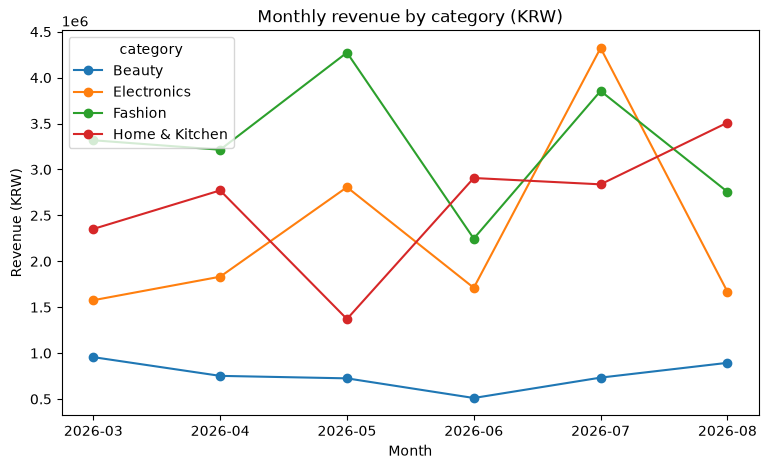

In [22]:
pivot.drop(columns="Total").plot(
    kind="line",
    marker="o",
    figsize=(9, 5),
    title="Monthly revenue by category (KRW)"
)

plt.ylabel("Revenue (KRW)")
plt.xlabel("Month")

plt.show()

In [23]:
city_segment_pivot = df.pivot_table(
    index="city",
    columns="segment",
    values="revenue",
    aggfunc="sum",
    fill_value=0
)

city_segment_pivot

segment,Premium,Regular,Unknown
city,,,
Busan,"573,000","10,602,000",0
Daegu,0,"9,372,000",0
Daejeon,"669,000","6,002,000",0
Gwangju,"54,000","2,163,000",0
Incheon,"5,218,000","2,440,000",0
Seoul,"1,270,000","14,923,000",0
Unknown,0,0,"618,000"


In [24]:
city_segment_analysis = city_segment_pivot.copy()

city_segment_analysis["Total"] = (
    city_segment_analysis.sum(axis=1)
)

if "Premium" in city_segment_analysis.columns:
    city_segment_analysis["Premium_Share_%"] = (
        city_segment_analysis["Premium"]
        / city_segment_analysis["Total"]
        * 100
    )

city_segment_analysis.sort_values(
    "Premium_Share_%",
    ascending=False
)

segment,Premium,Regular,Unknown,Total,Premium_Share_%
city,,,,,
Incheon,"5,218,000","2,440,000",0,"7,658,000",68
Daejeon,"669,000","6,002,000",0,"6,671,000",10
Seoul,"1,270,000","14,923,000",0,"16,193,000",8
Busan,"573,000","10,602,000",0,"11,175,000",5
Gwangju,"54,000","2,163,000",0,"2,217,000",2
Daegu,0,"9,372,000",0,"9,372,000",0
Unknown,0,0,"618,000","618,000",0


In [25]:
df.to_csv("orders_clean.csv", index=False)

print(
    "Saved orders_clean.csv with",
    df.shape[0],
    "rows and",
    df.shape[1],
    "columns"
)

Saved orders_clean.csv with 300 rows and 13 columns


In [26]:
## Findings

1. Revenue drivers: Fashion generated the highest total revenue among the product categories. Seoul generated the highest revenue among the cities.

2. Monthly trend: Revenue varied across March to August, with July being the strongest month and June being the weakest month.

3. Customers: Customer_16 was the highest-value customer. Some registered customers had never placed an order, and three orders were associated with customer ID 9999, which was not found in the CRM.

4. Data quality: The original dataset contained duplicated rows, missing values, inconsistent category labels, text-formatted prices, text-formatted dates, and unmatched customer IDs.

## Recommendations

1. Prioritize inventory, marketing, and sales efforts around high-performing categories such as Fashion while investigating why Beauty generates lower revenue.

2. Focus customer-retention and promotional strategies on high-value customers and Premium customers, while also investigating registered customers who have never made a purchase.

3. Improve the order-entry and CRM validation process to prevent duplicate submissions, missing customer references, inconsistent labels, and incomplete payment or quantity fields.

## Cleaning steps I applied (and why)

- Removed fully duplicated rows to prevent inflated revenue calculations.
- Converted `unit_price` from text into numeric values so revenue could be calculated correctly.
- Converted `order_date` into datetime format so dates could be grouped and analysed by month.
- Standardised category labels by removing extra spaces and normalising capitalisation.
- Filled missing quantity values using the median to preserve valid order records.
- Filled missing payment methods with `Unknown` rather than guessing a value.
- Created a `revenue` column using unit price multiplied by quantity.
- Created a `month` column for monthly trend analysis.
- Used a left join to preserve all order records when merging with customer data.
- Labelled unmatched CRM records as `Unknown` rather than deleting them.

SyntaxError: invalid syntax (2451222417.py, line 3)

In [ ]:
print("=== FINAL CHECK ===")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicates:", df.duplicated().sum())
print("Missing values:", df.isna().sum().sum())
print("Total revenue:", f"₩{df['revenue'].sum():,.0f}")

assert df.shape == (300, 13)
assert df.duplicated().sum() == 0
assert df.isna().sum().sum() == 0

print("\n✅ Final dataset passed all checks.")